# IMPORT CÁC THƯ VIỆN CẦN THIẾT


In [8]:
import pandas as pd
from pymongo import MongoClient
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# ĐỌC DỮ LIỆU VÀO 

In [9]:
dataset_tiktokers=pd.read_csv("dataset_tiktoker.csv",encoding='utf-8')

# 1.KHÁM PHÁ TỔNG QUAN ( DATA INSPECTION)

# Xem 5 dòng đầu của dữ liệu 

In [4]:
dataset_tiktokers.head()

,CREATOR_ID,VIDEO_ID,CREATE_TIME,FOLLOWERS,FOLLOWING_COUNT,ENGAGEMENT,TOTAL_LIKES,DIGG_COUNT,VIDEO_COUNT,COLLAB_SCORE,...,VIEW_COUNT,LIKE_COUNT,COMMENT_COUNT,SHARE_COUNT,SAVE_COUNT,VQSCORE,BITRATE,CATEGORY_TYPE,CATEGORY_y,PRICE_NUM
0,endersff,7574282336460737800,2026-01-09 15:03:48.0000000,433000,96,0.88,8200000,8948,684,87.8,...,11600000,45700,202,1074,1816,69.95,1100586.0,118,"News & Entertainment, Video Games",5000000.0
1,aigonew1ld,7583972786322885889,2025-12-28 15:20:00.0000000,67000,8,11.12,2200000,801,356,81.1,...,16300000,909700,9759,759100,74587,67.28,628871.0,113,"Movies & TV, Pet Tips & Care",12000000.0
2,khucanhhung,7585089116388379911,2025-12-28 20:00:00.0000000,163100,54,5.11,5800000,821,362,84.0,...,268400,7964,158,2353,149,69.48,681045.0,111,"Mukbang & Food Tasting, Home Improvement, Tech...",1500000.0
3,endersff,7585469260718296328,2025-12-25 16:35:31.0000000,433000,96,0.88,8200000,8948,684,87.8,...,10700,78,9,5,6,68.90,1018762.0,102,"News & Entertainment, Video Games",5000000.0
4,hieuride17x,7585789833734737172,2026-01-01 00:00:00.0000000,80600,213,13.80,2800000,136400,256,90.9,...,143200,22300,101,3764,1565,57.63,543016.0,101,"Movies & TV, Music",3000000.0


# Xem 5 dòng cuối của dữ liệu 

In [ ]:
dataset_tiktokers.tail()

# Xem 10 dòng dữ liệu ngẫu nhiên 

In [ ]:
dataset_tiktokers.sample(10)

In [5]:
dataset_tiktokers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208479 entries, 0 to 208478
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CREATOR_ID       208479 non-null  object 
 1   VIDEO_ID         208479 non-null  int64  
 2   CREATE_TIME      208479 non-null  object 
 3   FOLLOWERS        208479 non-null  int64  
 4   FOLLOWING_COUNT  208479 non-null  int64  
 5   ENGAGEMENT       208479 non-null  float64
 6   TOTAL_LIKES      208479 non-null  int64  
 7   DIGG_COUNT       208479 non-null  int64  
 8   VIDEO_COUNT      208479 non-null  int64  
 9   COLLAB_SCORE     206079 non-null  float64
 10  PRICE            0 non-null       float64
 11  CATEGORY_x       0 non-null       float64
 12  BROADCAST_SCORE  85257 non-null   float64
 13  ANCHOR_TYPES     37252 non-null   object 
 14  VIEW_COUNT       208479 non-null  int64  
 15  LIKE_COUNT       208479 non-null  int64  
 16  COMMENT_COUNT    208479 non-null  int6

Bộ dữ liệu có 208479 dòng và 24 cột đặc trưng

Các chỉ số ở các cột.

In [7]:
dataset_tiktokers.columns

Index(['CREATOR_ID', 'VIDEO_ID', 'CREATE_TIME', 'FOLLOWERS', 'FOLLOWING_COUNT',
       'ENGAGEMENT', 'TOTAL_LIKES', 'DIGG_COUNT', 'VIDEO_COUNT',
       'COLLAB_SCORE', 'PRICE', 'CATEGORY_x', 'BROADCAST_SCORE',
       'ANCHOR_TYPES', 'VIEW_COUNT', 'LIKE_COUNT', 'COMMENT_COUNT',
       'SHARE_COUNT', 'SAVE_COUNT', 'VQSCORE', 'BITRATE', 'CATEGORY_TYPE',
       'CATEGORY_y', 'PRICE_NUM'],
      dtype='object')

Bộ dữ liệu gồm 24 cột đặc trưng biểu diễn đầy đủ các thông số thương mại của một video, creator. 

# 2: LÀM SẠCH DỮ LIỆU ( DATA CLEANING )

# Đưa về đúng chuẩn NaN cho các ô dữ liệu thiếu 

In [15]:


# 1. Định nghĩa danh sách các chuỗi ký tự mạo danh giá trị rỗng
missing_values = ['', ' ', 'null', 'Null', 'NULL', 'N/A', 'n/a', 'NaN', 'None', '-']

# 2. Thay thế toàn bộ chúng thành np.nan (chuẩn giá trị rỗng của Python)
dataset_tiktokers = dataset_tiktokers.replace(missing_values, np.nan)

# 3. Danh sách các cột tương tác cần ép kiểu về định dạng số
numeric_columns = ['FOLLOWERS', 'VIEW_COUNT', 'LIKE_COUNT', 'COMMENT_COUNT', 'SHARE_COUNT', 'ENGAGEMENT']

for col in numeric_columns:
    # errors='coerce': Nếu gặp chuỗi ký tự lỗi không thể chuyển thành số, ép nó thành NaN luôn
    if col in dataset_tiktokers.columns:
        dataset_tiktokers[col] = pd.to_numeric(dataset_tiktokers[col], errors='coerce')

# 4. Kiểm tra xem mỗi cột đang có chính xác bao nhiêu dòng bị Null sau khi xử lý
null_counts = dataset_tiktokers.isna().sum()

print("Số lượng giá trị Null ở mỗi cột sau khi làm sạch bước 1:")
# Chỉ in ra những cột thực sự có chứa Null (giá trị > 0)
print(null_counts[null_counts > 0])

Số lượng giá trị Null ở mỗi cột sau khi làm sạch bước 1:
COLLAB_SCORE         2400
PRICE              208479
CATEGORY_x         208479
BROADCAST_SCORE    123222
ANCHOR_TYPES       171227
VQSCORE              8584
BITRATE              8584
CATEGORY_y           1950
dtype: int64


Có 4 cột dữ liệu bị thiếu hơn 50% dòng dữ liệu (104239) nên sẽ xóa đi để chuẩn bị cho model sau này 

# Xóa đi các cột bị thiếu hơn 50% dòng dữ liệu 

In [ ]:
# Danh sách 4 cột cần xóa
cac_cot_can_xoa = [
    'PRICE', 
    'CATEGORY_x',     
]

# Sử dụng hàm drop để xóa cột
# errors='ignore' giúp tránh báo lỗi nếu bạn vô tình chạy đoạn code này nhiều lần 
# (tức là nếu cột đã bị xóa rồi thì code sẽ tự động bỏ qua)
dataset_tiktokers = dataset_tiktokers.drop(columns=cac_cot_can_xoa, errors='ignore')

# In ra danh sách các cột còn lại để kiểm tra xem đã xóa thành công chưa
print("Danh sách các cột sau khi xóa:")
print(dataset_tiktokers.columns.tolist())

Danh sách các cột sau khi xóa:
['CREATOR_ID', 'VIDEO_ID', 'CREATE_TIME', 'FOLLOWERS', 'FOLLOWING_COUNT', 'ENGAGEMENT', 'TOTAL_LIKES', 'DIGG_COUNT', 'VIDEO_COUNT', 'COLLAB_SCORE', 'ANCHOR_TYPES', 'VIEW_COUNT', 'LIKE_COUNT', 'COMMENT_COUNT', 'SHARE_COUNT', 'SAVE_COUNT', 'VQSCORE', 'BITRATE', 'CATEGORY_TYPE', 'CATEGORY_y', 'PRICE_NUM']


# Xử lý dữ liệu thiếu cột ANCHOR_TYPES

In [17]:
# Bước 1: Phân loại 0 và 1
# Nếu không phải NaN (notna) thì trả về 1, ngược lại trả về 0
dataset_tiktokers['HAS_SHOP_LINK'] = dataset_tiktokers['ANCHOR_TYPES'].notna().astype(int)
# Bước 2: Kiểm tra kiểu dữ liệu (Đảm bảo là int)
print(f"Kiểu dữ liệu của cột HAS_SHOP_LINK: {dataset_tiktokers['HAS_SHOP_LINK'].dtype}")
# Xem thử vài dòng để xác nhận
print(dataset_tiktokers[['ANCHOR_TYPES', 'HAS_SHOP_LINK']].head(10))

Kiểu dữ liệu của cột HAS_SHOP_LINK: int32
  ANCHOR_TYPES  HAS_SHOP_LINK
0          NaN              0
1          NaN              0
2          NaN              0
3     [33, 54]              1
4          NaN              0
5         [33]              1
6          NaN              0
7     [54, 33]              1
8     [54, 33]              1
9    [106, 33]              1


# Trực quan số video gắn giỏ hàng 

C:\Users\Admin\AppData\Local\Temp\ipykernel_32736\1698574185.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset_tiktokers, x='HAS_SHOP_LINK', palette='viridis', ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_32736\1698574185.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Không gắn (0)', 'Có gắn (1)'])


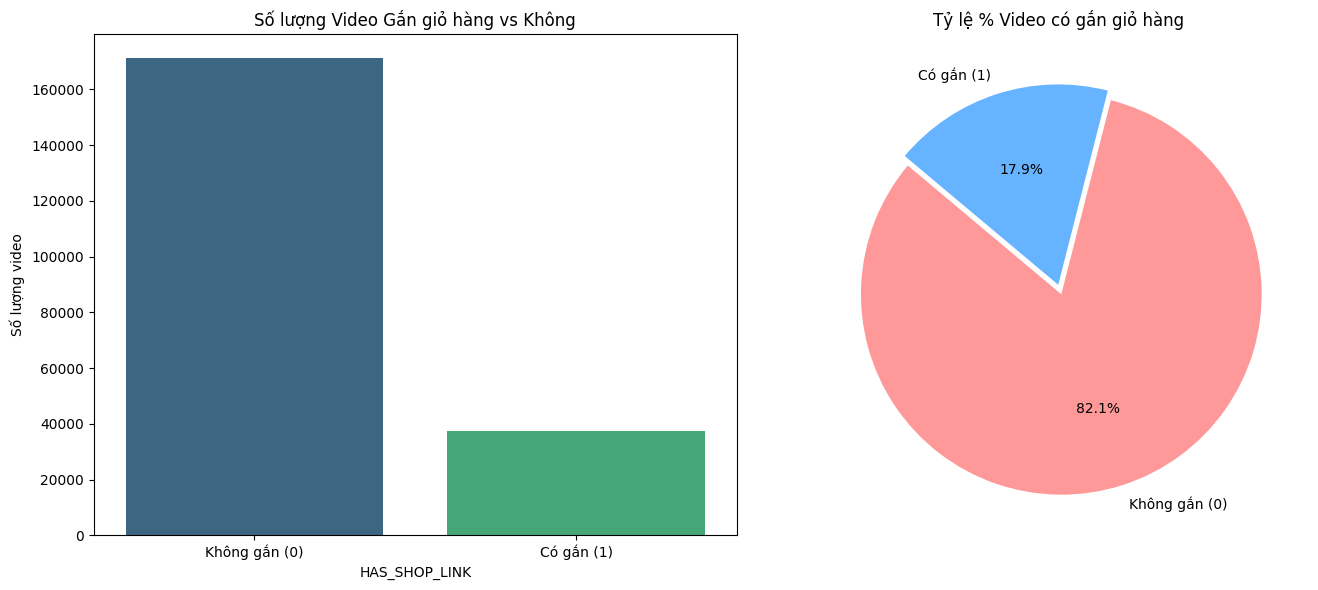

In [18]:
# Thiết lập giao diện biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Biểu đồ 1: Biểu đồ cột (Countplot)
sns.countplot(data=dataset_tiktokers, x='HAS_SHOP_LINK', palette='viridis', ax=axes[0])
axes[0].set_title('Số lượng Video Gắn giỏ hàng vs Không')
axes[0].set_xticklabels(['Không gắn (0)', 'Có gắn (1)'])
axes[0].set_ylabel('Số lượng video')

# Biểu đồ 2: Biểu đồ tròn (Pie chart) để xem tỷ lệ %
counts = dataset_tiktokers['HAS_SHOP_LINK'].value_counts()
axes[1].pie(counts, labels=['Không gắn (0)', 'Có gắn (1)'], autopct='%1.1f%%', 
            startangle=140, colors=['#ff9999','#66b3ff'], explode=(0.05, 0))
axes[1].set_title('Tỷ lệ % Video có gắn giỏ hàng')

plt.tight_layout()
plt.show()

# Điền thiếu cho các cột VQSCORE, BITRATE, CATEGORY_y, COLLAB_SCORE 
  

In [19]:
# 1. Điền giá trị thiếu cho BITRATE bằng số Trung vị
bitrate_median = dataset_tiktokers['BITRATE'].median()
dataset_tiktokers['BITRATE'] = dataset_tiktokers['BITRATE'].fillna(bitrate_median)

vqscore_median = dataset_tiktokers['VQSCORE'].median()
dataset_tiktokers['VQSCORE'] = dataset_tiktokers['VQSCORE'].fillna(vqscore_median)

# 2. Điền giá trị thiếu cho CATEGORY (y và type) bằng chữ 'Unknown'
dataset_tiktokers['CATEGORY_TYPE'] = dataset_tiktokers['CATEGORY_TYPE'].fillna('Unknown')
dataset_tiktokers['CATEGORY_y'] = dataset_tiktokers['CATEGORY_y'].fillna('Unknown')

# 3. Kiểm tra lại xem còn ô nào trống không
print("Số lượng ô trống còn lại sau khi xử lý:")
print(dataset_tiktokers[['BITRATE', 'VQSCORE', 'CATEGORY_TYPE', 'CATEGORY_y']].isna().sum())


Số lượng ô trống còn lại sau khi xử lý:
BITRATE          0
VQSCORE          0
CATEGORY_TYPE    0
CATEGORY_y       0
dtype: int64


# Kiểm tra số dòng bị trùng lặp

In [20]:
duplicate_rows = dataset_tiktokers.duplicated(subset=['CREATOR_ID', 'VIDEO_ID']).sum()
print(f"Phát hiện {duplicate_rows} dòng video bị trùng lặp.")

Phát hiện 0 dòng video bị trùng lặp.


# Chuẩn hóa kiểu dữ liệu cho cột CREAT_TIME


In [21]:
# Ép kiểu cột CREATE_TIME từ chuỗi (object) sang định dạng Thời gian (datetime)
dataset_tiktokers['CREATE_TIME'] = pd.to_datetime(dataset_tiktokers['CREATE_TIME'], errors='coerce')

# Kiểm tra lại xem Dtype của CREATE_TIME đã chuyển thành datetime64 chưa
print(dataset_tiktokers['CREATE_TIME'].dtype)

datetime64[ns]


# Gom nhóm theo CREATOR_ID 

In [22]:
# 1. Sắp xếp toàn bộ bảng dữ liệu theo cột CREATOR_ID
# Mình lồng thêm 'VIDEO_ID' để các video của cùng 1 người cũng được xếp theo thứ tự luôn cho đẹp
dataset_tiktokers = dataset_tiktokers.sort_values(by=['CREATOR_ID', 'VIDEO_ID'])

# 2. Reset lại cột số thứ tự (Index) ngoài cùng bên trái cho liền mạch từ 0, 1, 2...
dataset_tiktokers = dataset_tiktokers.reset_index(drop=True)

# 3. In thử 10 dòng đầu tiên của 2 cột này để xem đã đúng ý bạn chưa nhé
dataset_tiktokers.head(10)

,CREATOR_ID,VIDEO_ID,CREATE_TIME,FOLLOWERS,FOLLOWING_COUNT,ENGAGEMENT,TOTAL_LIKES,DIGG_COUNT,VIDEO_COUNT,COLLAB_SCORE,...,LIKE_COUNT,COMMENT_COUNT,SHARE_COUNT,SAVE_COUNT,VQSCORE,BITRATE,CATEGORY_TYPE,CATEGORY_y,PRICE_NUM,HAS_SHOP_LINK
0,._.ehe23,7587372080832826645,2025-12-24 17:38:52,34700,31,10.26,2400000,16800,396,79.6,...,811,11,12,125,67.99,1116554.0,120,Animation & Cosplay,1500000.0,0
1,._.ehe23,7588123135229103381,2025-12-26 18:13:22,34700,31,10.26,2400000,16800,396,79.6,...,897,16,18,126,67.99,1116554.0,120,Animation & Cosplay,1500000.0,0
2,._.ehe23,7591117134093176084,2026-01-03 19:51:38,34700,31,10.26,2400000,16800,396,79.6,...,1345,10,15,230,67.99,1116554.0,120,Animation & Cosplay,1500000.0,0
3,._.ehe23,7591450176611454229,2026-01-04 17:23:58,34700,31,10.26,2400000,16800,396,79.6,...,2548,8,103,231,71.82,1777545.0,100,Animation & Cosplay,1500000.0,0
4,._.ehe23,7591490606644333844,2026-01-04 20:00:53,34700,31,10.26,2400000,16800,396,79.6,...,343,3,4,33,67.99,1116554.0,120,Animation & Cosplay,1500000.0,0
5,._.ehe23,7592132371906923796,2026-01-06 13:31:16,34700,31,10.26,2400000,16800,396,79.6,...,321,7,4,34,64.97,1151292.0,120,Animation & Cosplay,1500000.0,0
6,._.ehe23,7592484953145871636,2026-01-07 12:19:30,34700,31,10.26,2400000,16800,396,79.6,...,502,3,0,53,67.99,1116554.0,120,Animation & Cosplay,1500000.0,0
7,._.ehe23,7595559059080711444,2026-01-15 19:08:34,34700,31,10.26,2400000,16800,396,79.6,...,985,6,19,178,67.99,1116554.0,120,Animation & Cosplay,1500000.0,0
8,._.ehe23,7598797696337513748,2026-01-24 12:36:11,34700,31,10.26,2400000,16800,396,79.6,...,856,10,13,125,70.03,668626.0,100,Animation & Cosplay,1500000.0,0
9,._.ehe23,7600272542657514773,2026-01-28 11:59:17,34700,31,10.26,2400000,16800,396,79.6,...,2508,12,105,335,67.99,1116554.0,120,Animation & Cosplay,1500000.0,0


Sau khi kiểm tra thì 0 dòng dữ liệu nào bị trùng lặp

# 3. TRỰC QUAN DỮ LIỆU 

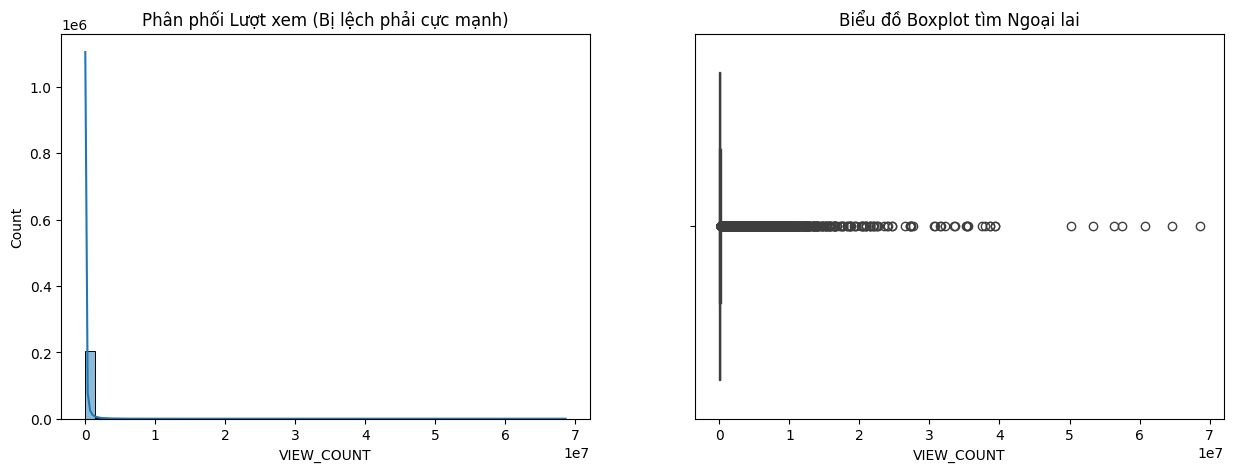

In [23]:

# Tạo khung hình gồm 2 biểu đồ nằm cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Vẽ Histogram để xem độ lệch (Distribution)
sns.histplot(dataset_tiktokers['VIEW_COUNT'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Phân phối Lượt xem (Bị lệch phải cực mạnh)')

# 2. Vẽ Boxplot để bắt các "chấm tròn" ngoại lai
sns.boxplot(x=dataset_tiktokers['VIEW_COUNT'], ax=axes[1])
axes[1].set_title('Biểu đồ Boxplot tìm Ngoại lai')

plt.show()

# Xử lý tình trạng mất cân bằng dữ liệu 


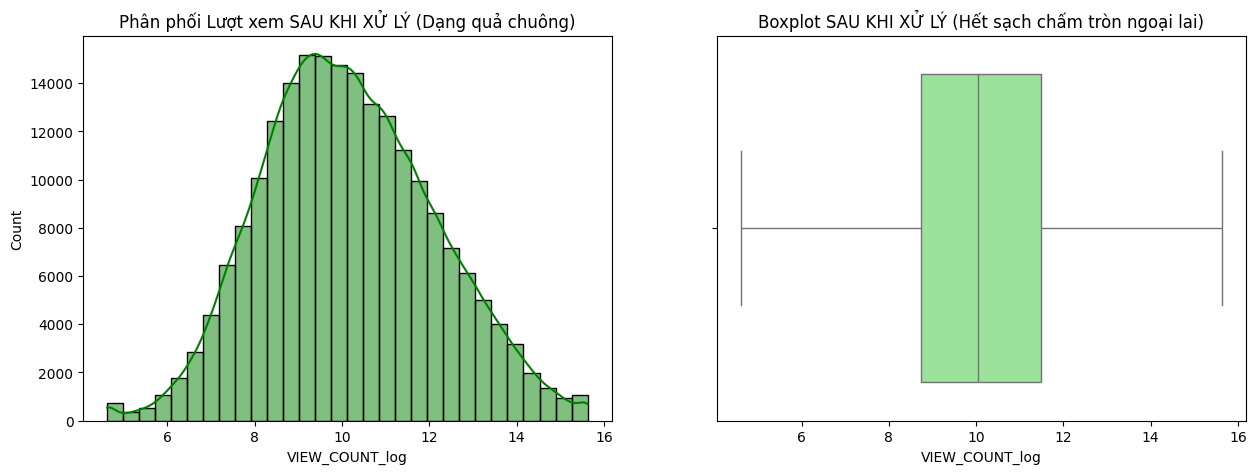

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các cột cần xử lý triệt để
cols_to_process = ['VIEW_COUNT', 'LIKE_COUNT', 'COMMENT_COUNT', 'SHARE_COUNT', 'FOLLOWERS']

# --- BƯỚC 1: LOG TRANSFORMATION ---
# Dùng log1p để xử lý các giá trị 0 (log(1+0) = 0)
for col in cols_to_process:
    dataset_tiktokers[col + '_log'] = np.log1p(dataset_tiktokers[col])

# --- BƯỚC 2: CAPPING OUTLIERS (Sử dụng IQR trên dữ liệu Log) ---
# Chúng ta sẽ giới hạn các giá trị quá lớn nằm ngoài "râu" của Boxplot
for col in [c + '_log' for c in cols_to_process]:
    Q1 = dataset_tiktokers[col].quantile(0.25)
    Q3 = dataset_tiktokers[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Xén các giá trị vượt trần và dưới sàn
    dataset_tiktokers[col] = np.clip(dataset_tiktokers[col], lower_bound, upper_bound)

# --- BƯỚC 3: KIỂM TRA LẠI THÀNH QUẢ ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram sau xử lý
sns.histplot(dataset_tiktokers['VIEW_COUNT_log'], bins=30, kde=True, ax=axes[0], color='green')
axes[0].set_title('Phân phối Lượt xem SAU KHI XỬ LÝ (Dạng quả chuông)')

# Boxplot sau xử lý
sns.boxplot(x=dataset_tiktokers['VIEW_COUNT_log'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot SAU KHI XỬ LÝ (Hết sạch chấm tròn ngoại lai)')

plt.show()

# Vẽ biểu đồ plot để so sánh 2 đặc trưng là lượt View và lượt Like 


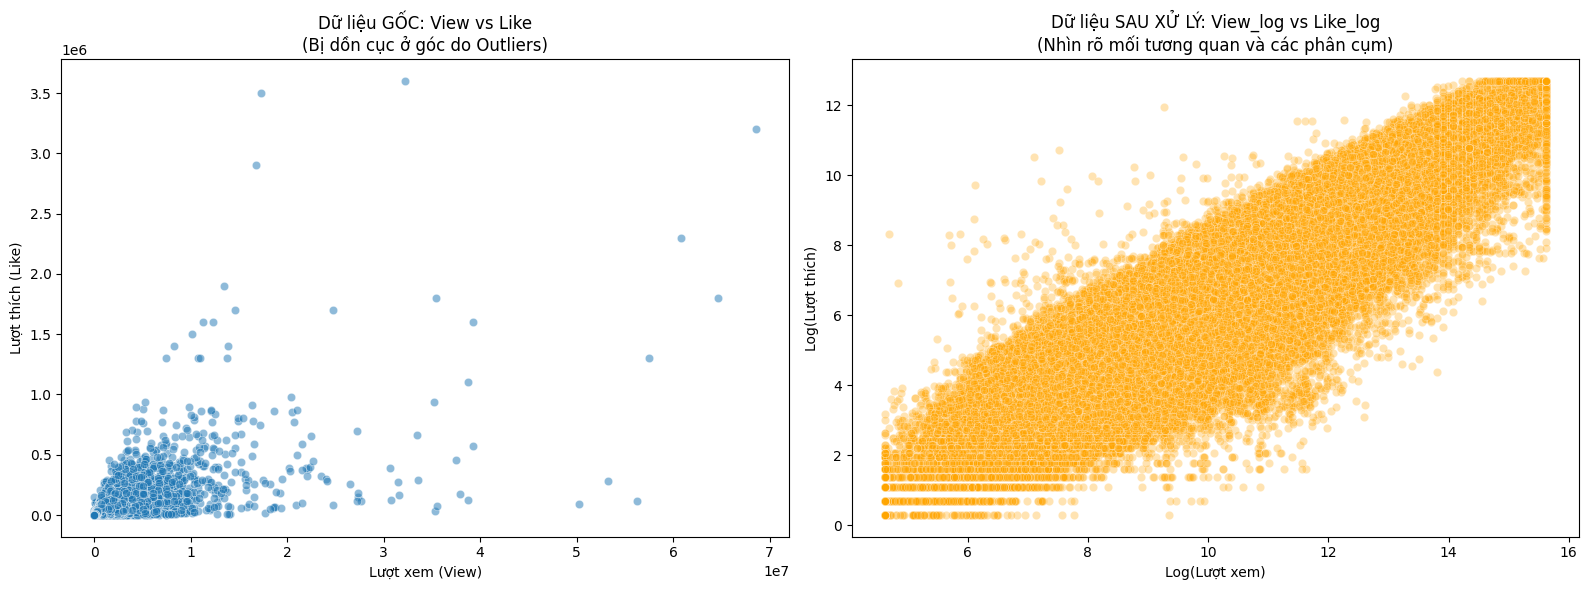

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo khung hình 1 hàng 2 cột
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter Plot với dữ liệu GỐC (Chưa xử lý)
sns.scatterplot(data=dataset_tiktokers, x='VIEW_COUNT', y='LIKE_COUNT', alpha=0.5, ax=axes[0])
axes[0].set_title('Dữ liệu GỐC: View vs Like\n(Bị dồn cục ở góc do Outliers)')
axes[0].set_xlabel('Lượt xem (View)')
axes[0].set_ylabel('Lượt thích (Like)')

# 2. Scatter Plot với dữ liệu SAU KHI LOG & CAPPING (Đã xử lý triệt để)
# Lưu ý: Sử dụng tên cột _log mà chúng ta đã tạo ở bước trước
sns.scatterplot(data=dataset_tiktokers, x='VIEW_COUNT_log', y='LIKE_COUNT_log', 
                alpha=0.3, color='orange', ax=axes[1])
axes[1].set_title('Dữ liệu SAU XỬ LÝ: View_log vs Like_log\n(Nhìn rõ mối tương quan và các phân cụm)')
axes[1].set_xlabel('Log(Lượt xem)')
axes[1].set_ylabel('Log(Lượt thích)')

plt.tight_layout()
plt.show()

# Trực quan khung giờ livestream của các CREATORS

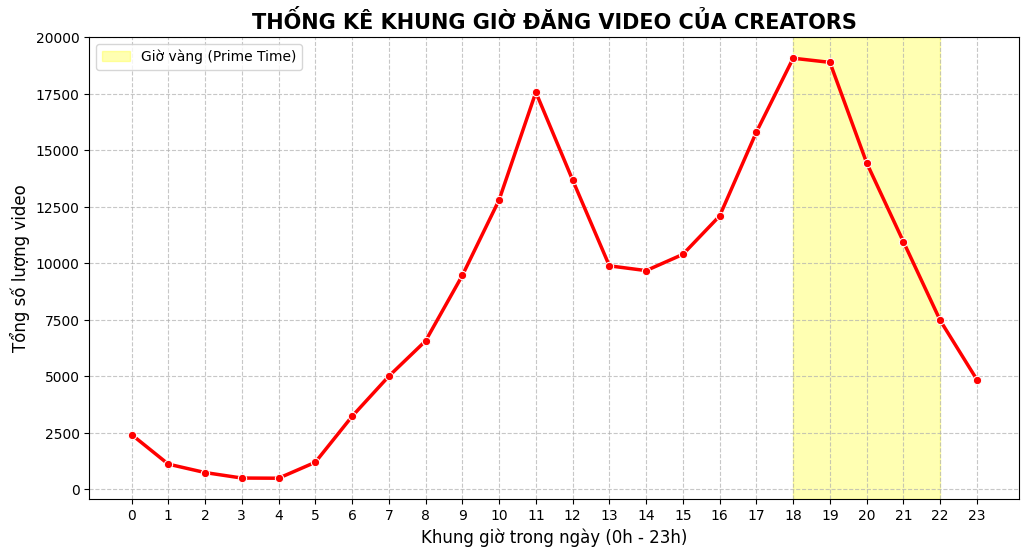

In [26]:


# 1. Trích xuất giờ từ cột CREATE_TIME
# Lưu ý: Đảm bảo bạn đã chạy lệnh pd.to_datetime cho cột này trước đó
dataset_tiktokers['hour'] = dataset_tiktokers['CREATE_TIME'].dt.hour

# 2. Tính toán số lượng video theo từng giờ
hourly_posts = dataset_tiktokers.groupby('hour')['VIDEO_ID'].count().reset_index()

# 3. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_posts, x='hour', y='VIDEO_ID', marker='o', color='red', linewidth=2.5)

# Làm đẹp biểu đồ
plt.title('THỐNG KÊ KHUNG GIỜ ĐĂNG VIDEO CỦA CREATORS', fontsize=15, fontweight='bold')
plt.xlabel('Khung giờ trong ngày (0h - 23h)', fontsize=12)
plt.ylabel('Tổng số lượng video', fontsize=12)
plt.xticks(range(0, 24)) # Hiện đủ 24 cột giờ
plt.grid(True, linestyle='--', alpha=0.7)

# Tô màu vùng cao điểm (ví dụ từ 18h - 22h) để dễ quan sát
plt.axvspan(18, 22, color='yellow', alpha=0.3, label='Giờ vàng (Prime Time)')
plt.legend()

plt.show()

# Trực quan phân tầng Creators theo lượt follow của họ 

Thống kê số lượng Creator theo tầng:
CREATOR_TIER
Nano         2868
Micro       68709
Mid-tier    90622
Macro       24512
Mega        21768
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_32736\3291981567.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_counts.index, y=tier_counts.values, palette='magma')


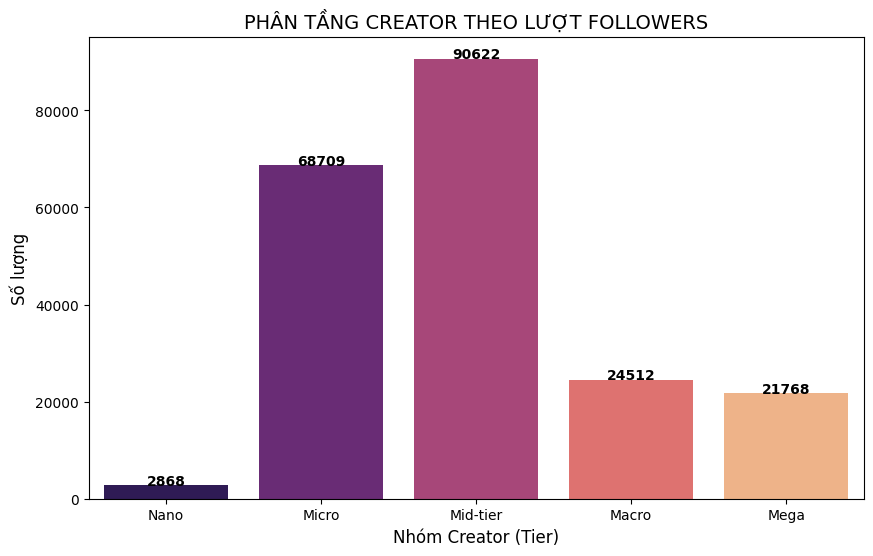

In [27]:
# 1. Định nghĩa các ngưỡng (bins) và nhãn (labels)
# Dùng np.inf để đại diện cho giá trị vô cùng (cho nhóm Mega)
bins = [0, 10000, 100000, 500000, 1000000, float('inf')]
labels = ['Nano', 'Micro', 'Mid-tier', 'Macro', 'Mega']

# 2. Tạo cột mới phân tầng Creator
# Lưu ý: Nếu bạn đang làm ở cấp độ Video, hãy cân nhắc Groupby theo Creator trước
dataset_tiktokers['CREATOR_TIER'] = pd.cut(dataset_tiktokers['FOLLOWERS'], 
                                           bins=bins, 
                                           labels=labels, 
                                           right=False)

# 3. Thống kê số lượng từng nhóm
tier_counts = dataset_tiktokers['CREATOR_TIER'].value_counts().reindex(labels)
print("Thống kê số lượng Creator theo tầng:")
print(tier_counts)

# 4. Trực quan hóa bằng biểu đồ cột
plt.figure(figsize=(10, 6))
sns.barplot(x=tier_counts.index, y=tier_counts.values, palette='magma')

# Thêm số liệu cụ thể lên đầu mỗi cột
for i, v in enumerate(tier_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.title('PHÂN TẦNG CREATOR THEO LƯỢT FOLLOWERS', fontsize=14)
plt.xlabel('Nhóm Creator (Tier)', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.show()

# Trực quan số video trong 90 ngày của 10 creator ngẫu nhiên 


C:\Users\Admin\AppData\Local\Temp\ipykernel_32736\673443447.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=video_counts.values, y=video_counts.index, palette='viridis')


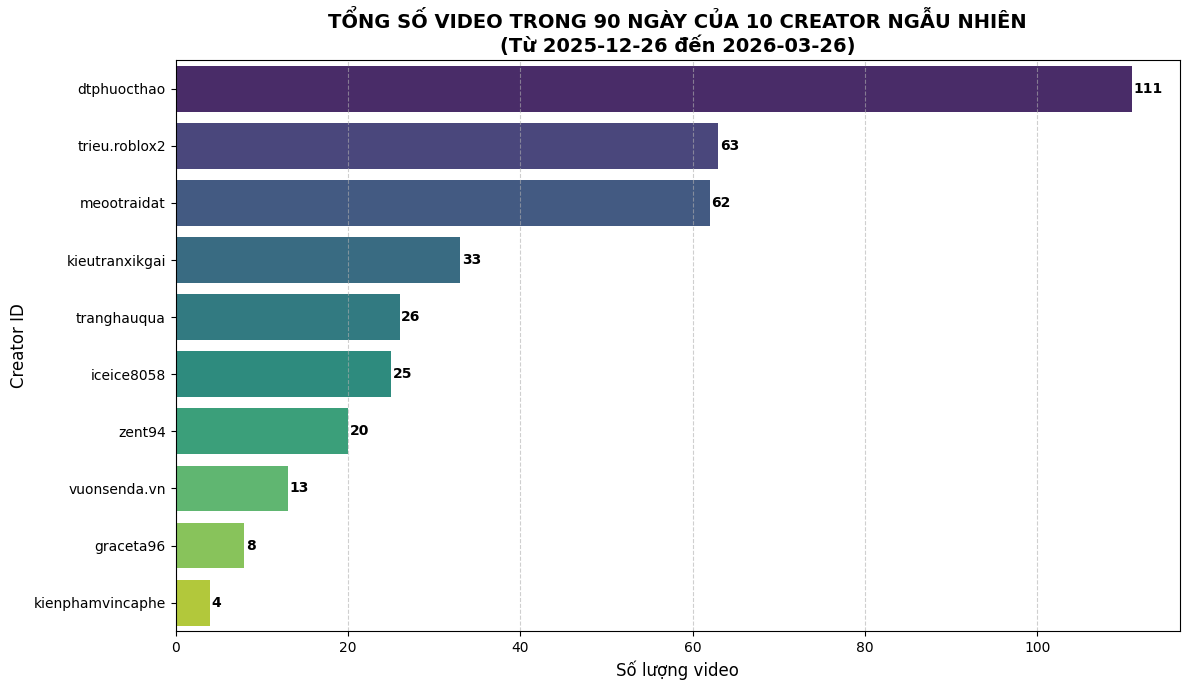

In [28]:

import random

# 1. Đảm bảo CREATE_TIME đã là datetime
dataset_tiktokers['CREATE_TIME'] = pd.to_datetime(dataset_tiktokers['CREATE_TIME'])

# 2. Lọc dữ liệu trong 90 ngày gần nhất
max_date = dataset_tiktokers['CREATE_TIME'].max()
ninety_days_ago = max_date - pd.Timedelta(days=90)
df_90d = dataset_tiktokers[dataset_tiktokers['CREATE_TIME'] >= ninety_days_ago].copy()

# 3. Chọn ngẫu nhiên 10 Creator có hoạt động trong 90 ngày này
random_creators = random.sample(list(df_90d['CREATOR_ID'].unique()), 10)
df_top_10 = df_90d[df_90d['CREATOR_ID'].isin(random_creators)]

# 4. Đếm số lượng video của mỗi Creator
video_counts = df_top_10.groupby('CREATOR_ID')['VIDEO_ID'].count().sort_values(ascending=False)

# 5. Vẽ biểu đồ
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=video_counts.values, y=video_counts.index, palette='viridis')

# Thêm số liệu cụ thể vào đầu mỗi cột
for i, v in enumerate(video_counts.values):
    ax.text(v + 0.2, i, str(v), color='black', va='center', fontweight='bold')

plt.title(f'TỔNG SỐ VIDEO TRONG 90 NGÀY CỦA 10 CREATOR NGẪU NHIÊN\n(Từ {ninety_days_ago.date()} đến {max_date.date()})', 
          fontsize=14, fontweight='bold')
plt.xlabel('Số lượng video', fontsize=12)
plt.ylabel('Creator ID', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

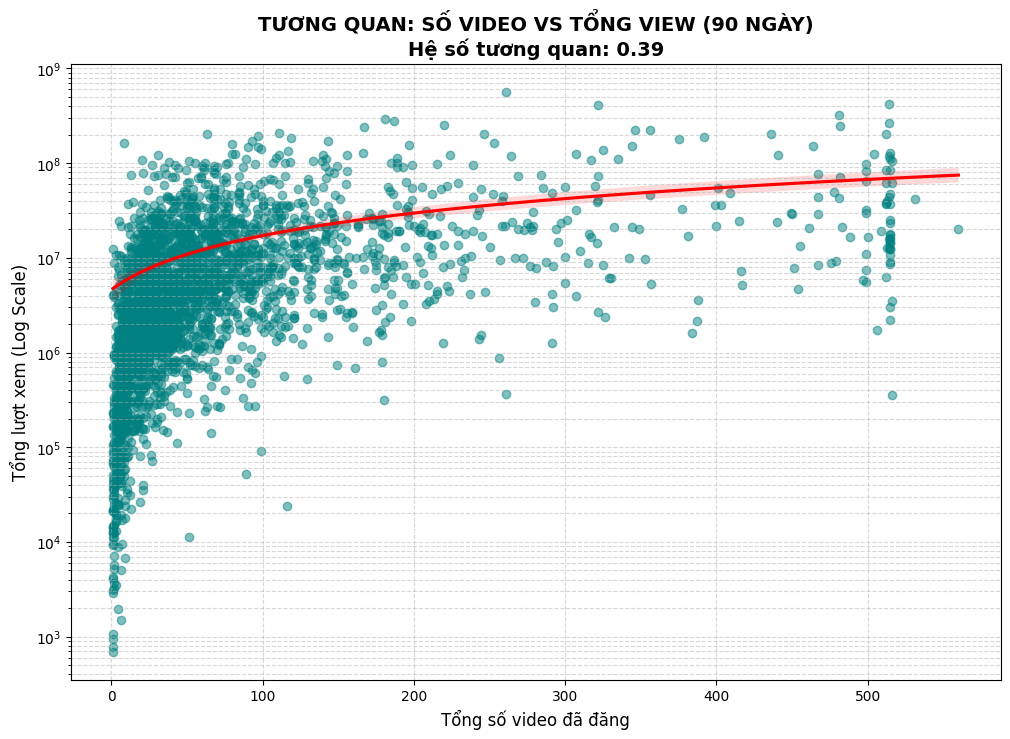

In [29]:
# 1. Xác định mốc thời gian 90 ngày
max_date = dataset_tiktokers['CREATE_TIME'].max()
ninety_days_ago = max_date - pd.Timedelta(days=90)

# 2. Lọc dữ liệu 90 ngày
df_90d = dataset_tiktokers[dataset_tiktokers['CREATE_TIME'] >= ninety_days_ago].copy()

# 3. Tính toán đặc trưng theo từng Creator
creator_stats_90d = df_90d.groupby('CREATOR_ID').agg({
    'VIDEO_ID': 'count',
    'VIEW_COUNT': 'sum'
}).rename(columns={'VIDEO_ID': 'TOTAL_VIDEOS_90D', 'VIEW_COUNT': 'TOTAL_VIEWS_90D'})

# 4. Tính hệ số tương quan Pearson
correlation = creator_stats_90d['TOTAL_VIDEOS_90D'].corr(creator_stats_90d['TOTAL_VIEWS_90D'])

# 5. Trực quan hóa bằng Scatter Plot (Dùng Log Scale để dễ nhìn vì View thường rất lớn)
plt.figure(figsize=(12, 8))
sns.regplot(data=creator_stats_90d, x='TOTAL_VIDEOS_90D', y='TOTAL_VIEWS_90D', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red'})

plt.yscale('log') # Dùng thang đo Log cho trục Y vì view biến thiên quá lớn
plt.title(f'TƯƠNG QUAN: SỐ VIDEO VS TỔNG VIEW (90 NGÀY)\nHệ số tương quan: {correlation:.2f}', 
          fontsize=14, fontweight='bold')
plt.xlabel('Tổng số video đã đăng', fontsize=12)
plt.ylabel('Tổng lượt xem (Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

In [30]:

# Config
MONGO_URI = os.getenv("MONGO_URI", "mongodb://localhost:27017")
MONGO_DB = "tiktok_ads_db"
MONGO_COLLECTION = "sample_direction1_category_stratified"

# Connect
client = MongoClient(MONGO_URI)
db = client[MONGO_DB]
collection = db[MONGO_COLLECTION]

# Load data
mongo_data = list(collection.find({}, {
    "_id": 0,
    "creator_id": 1,
    "price_num": 1,
    "category": 1
}))

df_mongo = pd.DataFrame(mongo_data)

# Tương quan giữ View của video có gắn giở hàng video không gắn giỏ hàng 

C:\Users\Admin\AppData\Local\Temp\ipykernel_32736\1298592689.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_view_shop, x='HAS_SHOP_LINK', y='view_log', palette='pastel', ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_32736\1298592689.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Không gắn (0)', 'Có gắn (1)'])


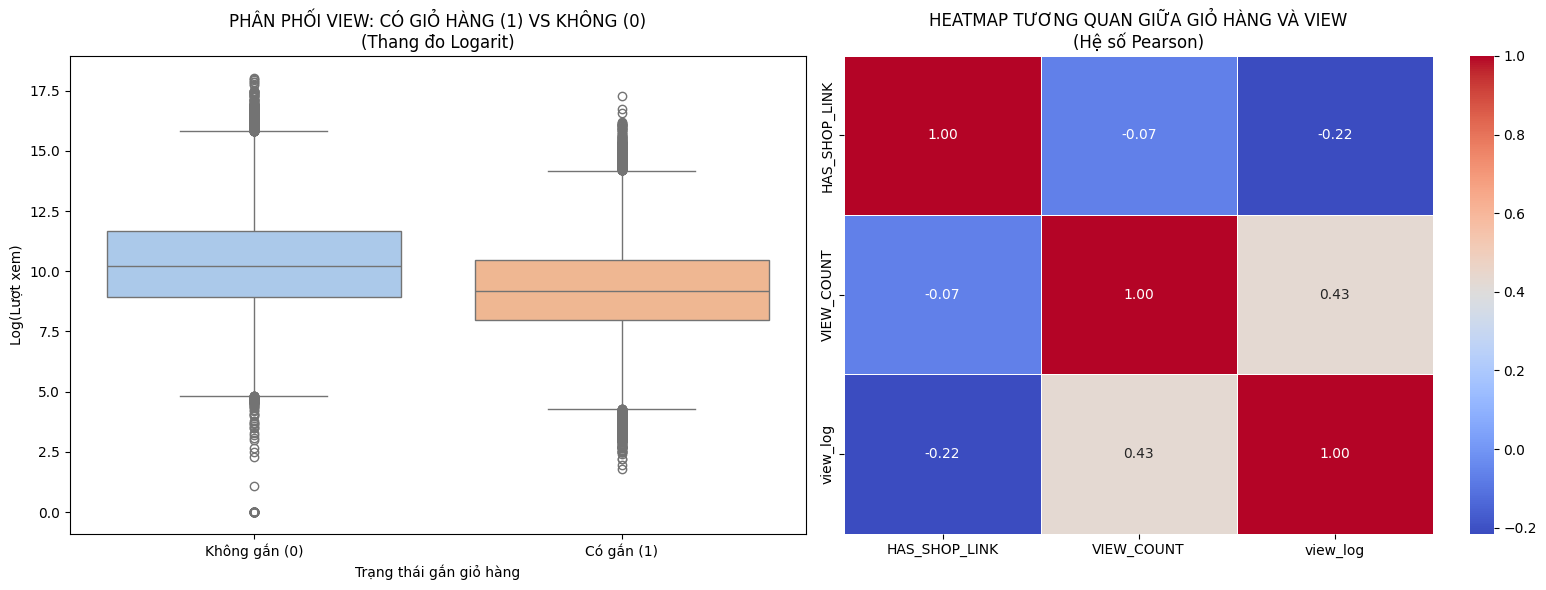

In [31]:


# 1. Đảm bảo dữ liệu 'HAS_SHOP_LINK' và 'VIEW_COUNT' đã chuẩn
# Lọc bỏ các dòng có View bị null
df_view_shop = dataset_tiktokers.dropna(subset=['VIEW_COUNT']).copy()

# Sử dụng thang đo Logarit cho View vì view chênh lệch quá lớn
# Log(1+x) để tránh lỗi với view = 0
df_view_shop['view_log'] = np.log1p(df_view_shop['VIEW_COUNT'])

# 2. Tạo khung hình gồm 2 biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: BOXPLOT SO SÁNH PHÂN PHỐI VIEW (LOG SCALE) ---
sns.boxplot(data=df_view_shop, x='HAS_SHOP_LINK', y='view_log', palette='pastel', ax=axes[0])
axes[0].set_title('PHÂN PHỐI VIEW: CÓ GIỎ HÀNG (1) VS KHÔNG (0)\n(Thang đo Logarit)')
axes[0].set_xticklabels(['Không gắn (0)', 'Có gắn (1)'])
axes[0].set_ylabel('Log(Lượt xem)')
axes[0].set_xlabel('Trạng thái gắn giỏ hàng')

# --- BIỂU ĐỒ 2: HEATMAP TƯƠNG QUAN BẰNG BIẾN NHỊ PHÂN ---
# Chúng ta tính tương quan giữa biến 0-1 (HAS_SHOP_LINK) và View
correlation_data = df_view_shop[['HAS_SHOP_LINK', 'VIEW_COUNT', 'view_log']]
corr_matrix = correlation_data.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[1])
axes[1].set_title('HEATMAP TƯƠNG QUAN GIỮA GIỎ HÀNG VÀ VIEW\n(Hệ số Pearson)')

plt.tight_layout()
plt.show()

Tiềm năng Viral: Cả hai nhóm đều có nhiều điểm ngoại lai (outliers) vọt lên cao, chứng tỏ video bán hàng vẫn có khả năng lên xu hướng, nhưng tần suất không cao bằng video giải trí thuần túy.

In [32]:
dataset_tiktokers.columns

Index(['CREATOR_ID', 'VIDEO_ID', 'CREATE_TIME', 'FOLLOWERS', 'FOLLOWING_COUNT',
       'ENGAGEMENT', 'TOTAL_LIKES', 'DIGG_COUNT', 'VIDEO_COUNT',
       'COLLAB_SCORE', 'ANCHOR_TYPES', 'VIEW_COUNT', 'LIKE_COUNT',
       'COMMENT_COUNT', 'SHARE_COUNT', 'SAVE_COUNT', 'VQSCORE', 'BITRATE',
       'CATEGORY_TYPE', 'CATEGORY_y', 'PRICE_NUM', 'HAS_SHOP_LINK',
       'VIEW_COUNT_log', 'LIKE_COUNT_log', 'COMMENT_COUNT_log',
       'SHARE_COUNT_log', 'FOLLOWERS_log', 'hour', 'CREATOR_TIER'],
      dtype='object')

In [38]:
# dataset_tiktokers.drop(columns=['ANCHOR_TYPES','LIKE_COUNT_log','COMMENT_COUNT_log','SHARE_COUNT_log','FOLLOWERS_log','VIEW_COUNT_log' ], inplace=True, errors='ignore')
dataset_tiktokers.describe().to_csv("dataset_tiktokers_describe_cleaned.csv",index=False)

In [34]:
# dataset_tiktokers['DAY_OF_WEEK'] = dataset_tiktokers['CREATE_TIME'].dt.weekday

In [35]:
# dataset_tiktokers.info()

In [36]:
# dataset_tiktokers.to_csv("dataset_tiktokers_cleaned.csv", index=False, encoding='utf-8')

In [ ]:
# df = dataset_tiktokers.head(800)
# df.to_csv("dataset_tiktokers_sample_800.csv", index=False, encoding='utf-8')